# Judge agreement: Claude 4.8 vs GPT-5.5 vs deterministic checks

How do our two LLM judges (`claude-opus-4.8`, `gpt-5.5`) and the **deterministic
checks** agree when scoring the same answers? This notebook applies the standard
*method-comparison / inter-rater agreement* toolkit, so the paper can claim the
quality ranking is **not a single-grader artifact**.

**Metrics** (grounded in the inter-rater-reliability literature):
- **Cohen's κ** — chance-corrected agreement; **quadratic-weighted (QWK)** is the
  right variant for ordinal 1–5 scores (Cohen 1968). Bands: Landis & Koch (1977).
- **Pearson r / Spearman ρ / Kendall τ** — linear / rank agreement.
- **ICC(2,1)** — intraclass correlation, two-way random (Shrout & Fleiss 1979);
  ≈ QWK for two raters (Fleiss & Cohen 1973).
- **Exact / within-1 agreement** — raw, interpretable.

**Plots** (how method/rater differences are conventionally shown):
- **Bland–Altman** (a.k.a. Tukey mean-difference) — *the* method-comparison plot
  (Bland & Altman, Lancet 1986): mean of the pair vs their difference, with the
  **bias** line and **95 % limits of agreement**. Reveals systematic bias and
  whether disagreement depends on the score level.
- **Scatter vs identity (y=x)** + **5×5 confusion heatmap** — where they land.
- **Score distributions** — leniency / marginal bias.
- **Per-model ranking** + **deterministic-vs-judge** + **agreement by task class**.

> The deterministic checks use a *different ruler* (0–1 partial credit) than the
> judge (1–5 holistic), so expect a **fixed offset**: the Bland–Altman and the
> det-vs-judge cell quantify it. Same ordering, different altitude.


In [ ]:
# === Environment bootstrap (Colab / Kaggle / Binder / local) — run me first ===
# If the committed data is not reachable (Colab/Kaggle opened just the .ipynb),
# clone the repo so data/snapshots/*.csv resolve. No-op on Binder/local.
# Kaggle: enable Settings -> Internet first so the clone can run.
import sys, os, subprocess

def _repo_data_present():
    here = os.getcwd()
    for _ in range(4):
        if os.path.exists(os.path.join(here, "data/snapshots/results_snapshot.csv")):
            return True
        here = os.path.dirname(here)
    return False

if not _repo_data_present():
    if not os.path.isdir("apprenticeops"):
        subprocess.run(["git", "clone", "--depth", "1",
                        "https://github.com/dragoshont/apprenticeops.git"], check=True)
    os.chdir("apprenticeops")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "pandas", "numpy", "matplotlib", "scipy"], check=True)

In [1]:
# --- ensure the analysis stack imports in WHATEVER kernel runs this ---
# System Python has none of these; the repo .venv (kernel "apprenticeops (.venv)")
# has them. If you're on the wrong kernel, this installs them into it so scipy &
# friends still load. Best: pick the "apprenticeops (.venv)" kernel (top-right).
import importlib, subprocess, sys
for _pkg in ("numpy", "pandas", "matplotlib", "scipy"):
    try:
        importlib.import_module(_pkg)
    except ImportError:
        print(f"installing {_pkg} into {sys.executable} …")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", _pkg])

import os, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats   # <- the import you asked to make sure loads

# --- repo root (so .tmp/ and data/ paths resolve from anywhere) ---
ROOT = Path.cwd()
while not (ROOT / "data" / "scenarios.json").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
os.chdir(ROOT)

# --- which pass? "var" = R=5 variance (five samples/scenario; the DEFAULT now
#     the variance judges are done) ; "det" = temp-0 single sample. Flip back to
#     "det" for the single-sample view. ---
PASS = "var"
PATHS = {
    "det": dict(claude=".tmp/judge/judged.det.jsonl",
                gpt=".tmp/judge/judged.det.gpt55.jsonl",
                results=".tmp/judge/results.det.jsonl"),
    "var": dict(claude=".tmp/judge/judged.var.claude.jsonl",
                gpt=".tmp/judge/judged.var.gpt55.jsonl",
                results=".tmp/judge/results.var.jsonl"),
}[PASS]
SCEN = "data/scenarios.json"
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
print("python :", sys.executable)
print("scipy  :", stats.__name__, "loaded | numpy", np.__version__, "| pandas", pd.__version__)
print("root   :", ROOT, "| pass:", PASS)

python : /Users/dragoshont/Repo/apprenticeops/.venv/bin/python
scipy  : scipy.stats loaded | numpy 2.4.6 | pandas 3.0.3
root   : /Users/dragoshont/Repo/apprenticeops | pass: var


In [2]:
def _scen_class():
    sj = json.load(open(SCEN))
    items = sj.get("scenarios", sj) if isinstance(sj, dict) else sj
    return {s["id"]: s.get("class") for s in items}

if PASS == "var":
    # Consolidated 94-model dataset, reproducible from COMMITTED exports:
    # per-judge pairs (data/site/judge_pairs.csv, both judges, 8,909 reps) +
    # det/bracket (results_snapshot.csv) + class (scenarios.json).
    df = pd.read_csv("data/site/judge_pairs.csv")
    df["rep"] = df["rep"].astype(str)
    rs = pd.read_csv("data/snapshots/results_snapshot.csv",
                     usecols=["model", "scenario", "rep", "det_score", "bracket"])
    rs["rep"] = rs["rep"].astype(str)
    df = df.merge(rs.rename(columns={"det_score": "det"}),
                  on=["model", "scenario", "rep"], how="left")
    df["class"] = df["scenario"].map(_scen_class())
else:
    def load_scores(path, col):
        rows = []
        for line in open(path):
            line = line.strip()
            if not line:
                continue
            o = json.loads(line)
            s = o.get("score")
            if s is None:
                continue
            rows.append((o["model"], o["scenario"], str(o.get("rep")), int(round(float(s)))))
        return pd.DataFrame(rows, columns=["model", "scenario", "rep", col])
    claude = load_scores(PATHS["claude"], "claude")
    gpt = load_scores(PATHS["gpt"], "gpt")
    dt = []
    for line in open(PATHS["results"]):
        line = line.strip()
        if not line:
            continue
        o = json.loads(line)
        if not o.get("scenario"):
            continue
        dt.append((o["model"], o["scenario"], str(o.get("rep", "0")),
                   o.get("det_score"), o.get("bracket"), o.get("class")))
    det = pd.DataFrame(dt, columns=["model", "scenario", "rep", "det", "bracket", "class"])
    df = (claude.merge(gpt, on=["model", "scenario", "rep"])
                .merge(det, on=["model", "scenario", "rep"], how="left"))

df["det"] = pd.to_numeric(df["det"], errors="coerce")
df["det5"] = df["det"] * 4 + 1   # 0..1 partial-credit -> 1..5 for same-axis comparison
DNF = {"phi:2.7b"}               # served-failure, excluded from the paper
df = df[~df.model.isin(DNF)].reset_index(drop=True)
print(f"{len(df)} jointly-scored answers, {df.model.nunique()} models, "
      f"{df['class'].nunique()} classes")
df.head()

8909 jointly-scored answers, 94 models, 10 classes


,model,scenario,rep,claude,gpt,bracket,det,class,det5
0,deepseek-coder:1.3b,augment-07-events-to-json,0,1,1,1-2B,0.000,augment,1.000
1,deepseek-coder:1.3b,augment-07-events-to-json,1,1,1,1-2B,0.000,augment,1.000
2,deepseek-coder:1.3b,augment-07-events-to-json,2,1,1,1-2B,0.000,augment,1.000
3,deepseek-coder:1.3b,augment-07-events-to-json,4,1,1,1-2B,0.600,augment,3.400
4,deepseek-coder:1.3b,detect-01-crashloop-triage,0,1,1,1-2B,0.667,detect,3.668


## 1. Headline agreement metrics

The chance-corrected, rank, and raw numbers in one place. QWK is the headline for
ordinal scores; ICC(2,1) is the continuous analogue.

In [3]:
def confusion(a, b, cats):
    idx = {c: i for i, c in enumerate(cats)}
    O = np.zeros((len(cats), len(cats)))
    for x, y in zip(a, b):
        O[idx[x], idx[y]] += 1
    return O

def cohen_kappa(a, b, weights=None):
    cats = sorted(set(a) | set(b))
    k = len(cats)
    O = confusion(a, b, cats)
    n = O.sum()
    row, col = O.sum(1), O.sum(0)
    E = np.outer(row, col) / n
    if weights == "quadratic":
        W = np.array([[(i - j) ** 2 for j in range(k)] for i in range(k)], float) / (k - 1) ** 2
    elif weights == "linear":
        W = np.array([[abs(i - j) for j in range(k)] for i in range(k)], float) / (k - 1)
    else:
        W = 1 - np.eye(k)
    return 1 - (W * O).sum() / (W * E).sum()

def icc_2_1(a, b):
    # two-way random, single-measure ICC(2,1) (Shrout & Fleiss 1979)
    Y = np.column_stack([a, b]).astype(float)
    n, k = Y.shape
    gm = Y.mean()
    MSR = k * ((Y.mean(1) - gm) ** 2).sum() / (n - 1)          # between subjects
    MSC = n * ((Y.mean(0) - gm) ** 2).sum() / (k - 1)          # between raters
    MSE = ((Y - Y.mean(1, keepdims=True) - Y.mean(0, keepdims=True) + gm) ** 2).sum() / ((n - 1) * (k - 1))
    return (MSR - MSE) / (MSR + (k - 1) * MSE + k * (MSC - MSE) / n)

def landis_koch(kp):
    for lo, name in [(.81, "almost perfect"), (.61, "substantial"), (.41, "moderate"),
                     (.21, "fair"), (0, "slight")]:
        if kp >= lo:
            return name
    return "poor"

a, b = df.claude.values, df.gpt.values
rows = [
    ("Cohen's κ (unweighted)", cohen_kappa(a, b)),
    ("Cohen's κ (linear)", cohen_kappa(a, b, "linear")),
    ("Cohen's κ (quadratic, QWK)", cohen_kappa(a, b, "quadratic")),
    ("ICC(2,1)", icc_2_1(a, b)),
    ("Pearson r", stats.pearsonr(a, b)[0]),
    ("Spearman ρ", stats.spearmanr(a, b)[0]),
    ("Kendall τ", stats.kendalltau(a, b)[0]),
    ("exact agreement", (a == b).mean()),
    ("within-1 agreement", (np.abs(a - b) <= 1).mean()),
    ("mean |Claude − GPT|", np.abs(a - b).mean()),
]
summary = pd.DataFrame(rows, columns=["metric", "value"]).set_index("metric")
summary["band"] = [landis_koch(v) if "κ" in m else "" for m, v in rows]
print(f"Claude mean={a.mean():.2f}   GPT-5.5 mean={b.mean():.2f}   (n={len(a)} answers)")
summary.round(3)


Claude mean=2.21   GPT-5.5 mean=2.23   (n=8909 answers)


,value,band
metric,,
Cohen's κ (unweighted),0.694,substantial
Cohen's κ (linear),0.813,almost perfect
"Cohen's κ (quadratic, QWK)",0.906,almost perfect
"ICC(2,1)",0.906,
Pearson r,0.909,
Spearman ρ,0.902,
Kendall τ,0.855,
exact agreement,0.773,
within-1 agreement,0.998,


## 2. Bland–Altman (method-comparison) plot

The canonical way to show agreement between two raters/methods (Bland & Altman
1986). x = the average of the two scores, y = their difference. The solid line is
the **bias** (mean difference); dashed lines are the **95 % limits of agreement**
(bias ± 1.96·SD). A flat cloud centred on 0 = unbiased agreement; a slope =
the disagreement depends on the score level. Points are jittered (scores are
discrete).

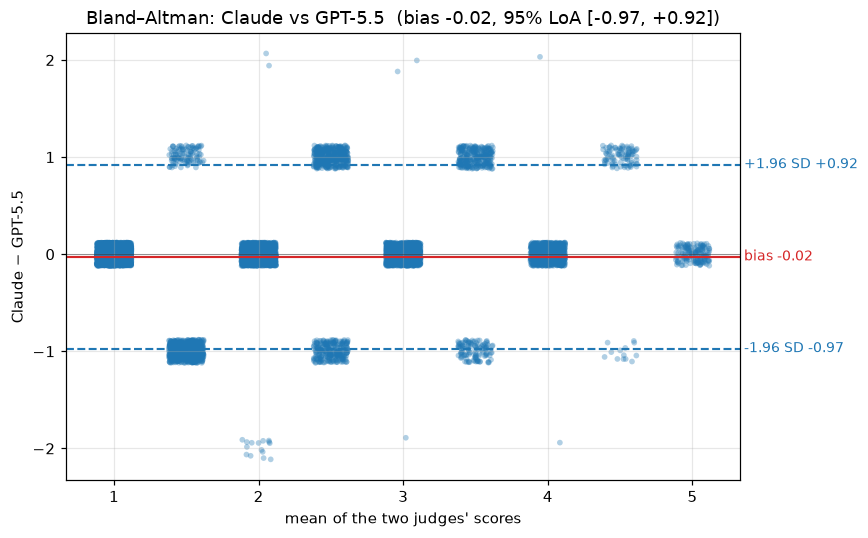

In [4]:
rng = np.random.default_rng(0)
mean_ab = (df.claude + df.gpt) / 2
diff = (df.claude - df.gpt).astype(float)
bias = diff.mean()
sd = diff.std(ddof=1)
lo, hi = bias - 1.96 * sd, bias + 1.96 * sd

jx = mean_ab + rng.uniform(-0.12, 0.12, len(df))
jy = diff + rng.uniform(-0.12, 0.12, len(df))
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(jx, jy, s=14, alpha=0.35, edgecolor="none")
for y, t, c in [(bias, f"bias {bias:+.2f}", "C3"), (hi, f"+1.96 SD {hi:+.2f}", "C0"),
                (lo, f"-1.96 SD {lo:+.2f}", "C0")]:
    ax.axhline(y, color=c, ls="--" if c == "C0" else "-", lw=1.4)
    ax.text(ax.get_xlim()[1], y, " " + t, va="center", color=c, fontsize=9)
ax.axhline(0, color="k", lw=0.6, alpha=0.4)
ax.set_xlabel("mean of the two judges' scores")
ax.set_ylabel("Claude − GPT-5.5")
ax.set_title(f"Bland–Altman: Claude vs GPT-5.5  (bias {bias:+.2f}, "
             f"95% LoA [{lo:+.2f}, {hi:+.2f}])")
plt.tight_layout(); plt.show()


## 3. Scatter vs the identity line + confusion matrix

Left: each answer's two scores, jittered, against **y = x** (perfect agreement).
Right: the 5×5 confusion of the discrete scores — the diagonal is exact
agreement, off-diagonal mass shows *how* they disagree.

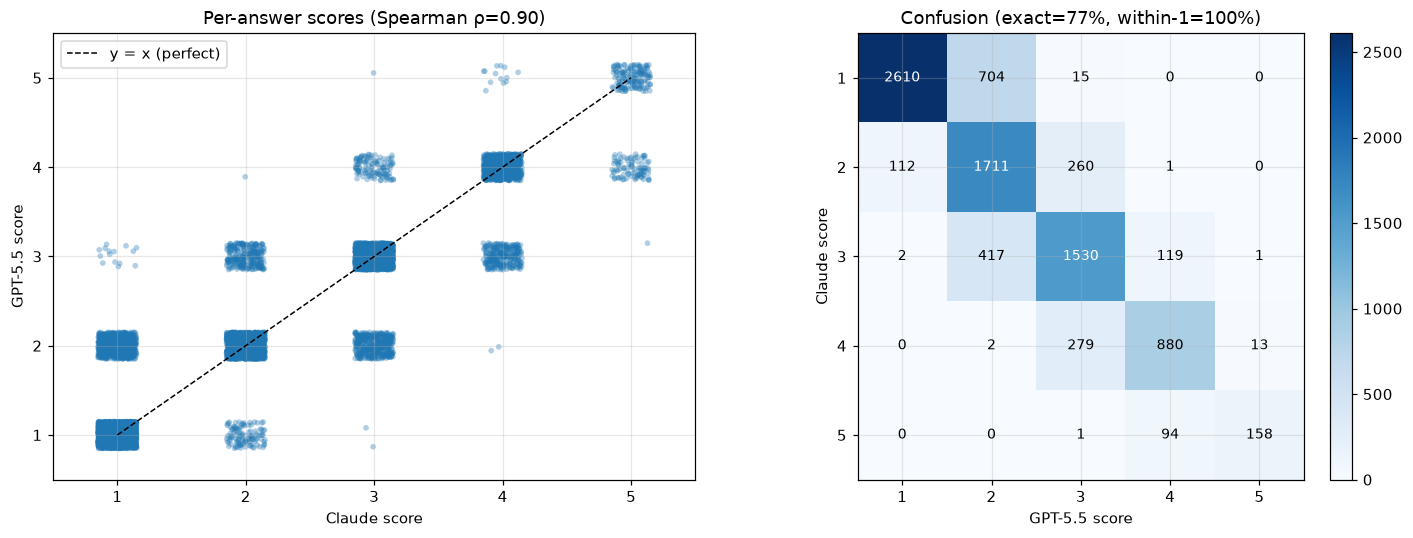

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# scatter vs identity
jx = df.claude + rng.uniform(-0.15, 0.15, len(df))
jy = df.gpt + rng.uniform(-0.15, 0.15, len(df))
ax1.scatter(jx, jy, s=14, alpha=0.35, edgecolor="none")
ax1.plot([1, 5], [1, 5], "k--", lw=1, label="y = x (perfect)")
ax1.set(xlim=(0.5, 5.5), ylim=(0.5, 5.5), xlabel="Claude score", ylabel="GPT-5.5 score",
        title=f"Per-answer scores (Spearman ρ={stats.spearmanr(a, b)[0]:.2f})")
ax1.legend(loc="upper left")

# confusion heatmap
cats = [1, 2, 3, 4, 5]
O = confusion(a, b, cats).astype(int)
im = ax2.imshow(O, cmap="Blues")
ax2.set_xticks(range(5), cats); ax2.set_yticks(range(5), cats)
ax2.set(xlabel="GPT-5.5 score", ylabel="Claude score",
        title=f"Confusion (exact={ (a==b).mean():.0%}, within-1={ (np.abs(a-b)<=1).mean():.0%})")
for i in range(5):
    for j in range(5):
        ax2.text(j, i, O[i, j], ha="center", va="center",
                 color="white" if O[i, j] > O.max() / 2 else "black", fontsize=9)
fig.colorbar(im, ax=ax2, fraction=0.046, pad=0.04)
plt.tight_layout(); plt.show()


## 4. Score distributions (leniency / marginal bias)

If one judge systematically scores higher, the histograms shift. Near-identical
marginal distributions mean no leniency bias — a precondition for a fair κ.

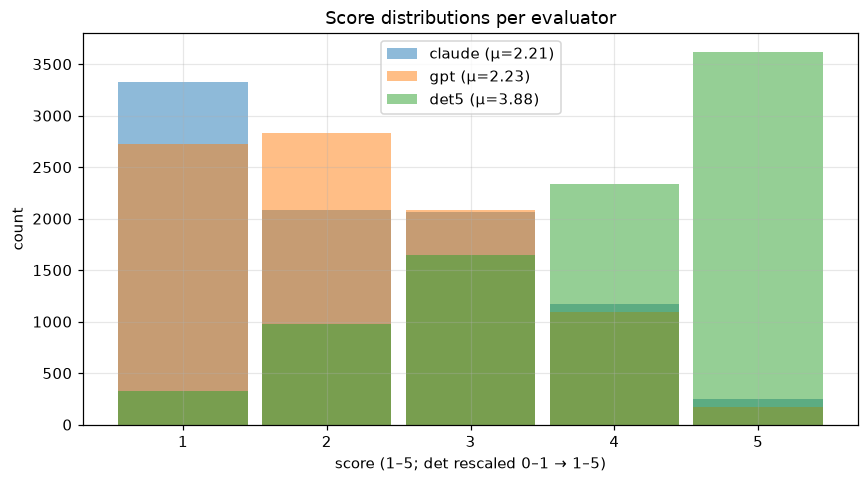

In [6]:
fig, ax = plt.subplots(figsize=(8, 4.5))
bins = np.arange(0.5, 6.5, 1)
for col, color in [("claude", "C0"), ("gpt", "C1"), ("det5", "C2")]:
    vals = df[col].dropna()
    ax.hist(vals, bins=bins, alpha=0.5, label=f"{col} (μ={vals.mean():.2f})",
            color=color, rwidth=0.9)
ax.set_xticks([1, 2, 3, 4, 5])
ax.set(xlabel="score (1–5; det rescaled 0–1 → 1–5)", ylabel="count",
       title="Score distributions per evaluator")
ax.legend(); plt.tight_layout(); plt.show()


## 5. Per-model ranking — do the evaluators agree on *which model is better*?

The decision a practitioner cares about is the **ranking**. Each evaluator's
per-model mean as **% of frontier** (judge ÷ 5; det ×100). If the lines track,
the ranking is robust to the choice of evaluator.

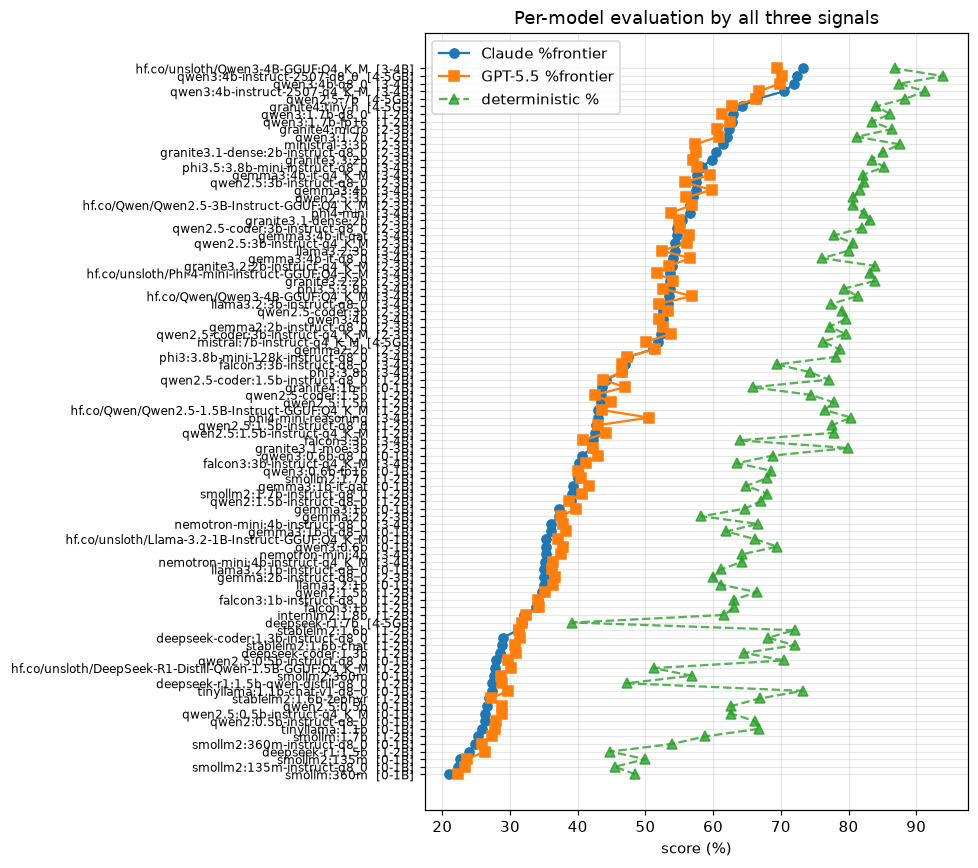

,claude,gpt,det,bracket
model,,,,
smollm:360m,21.1,22.3,48.5,0-1B
smollm2:135m-instruct-q8_0,22.3,23.4,45.5,0-1B
smollm2:135m,22.6,23.6,50.0,0-1B
deepseek-r1:1.5b,24.0,26.3,44.8,1-2B
smollm2:360m-instruct-q8_0,24.8,25.9,53.9,0-1B
...,...,...,...,...
qwen2.5:7b,66.5,66.3,88.4,4-5GB
qwen3:4b-instruct-2507-q4_K_M,70.5,66.7,91.3,3-4B
qwen3:4b-q8_0,72.0,69.9,87.5,3-4B


In [7]:
pm = (df.groupby("model")
        .agg(claude=("claude", "mean"), gpt=("gpt", "mean"),
             det=("det", "mean"), bracket=("bracket", "first"))
        .assign(claude=lambda d: d.claude / 5 * 100,
                gpt=lambda d: d.gpt / 5 * 100,
                det=lambda d: d.det * 100)
        .sort_values("claude", ascending=True))

fig, ax = plt.subplots(figsize=(9, 8))
y = np.arange(len(pm))
ax.plot(pm.claude, y, "o-", label="Claude %frontier", color="C0")
ax.plot(pm.gpt, y, "s-", label="GPT-5.5 %frontier", color="C1")
ax.plot(pm.det, y, "^--", label="deterministic %", color="C2", alpha=0.8)
ax.set_yticks(y, [f"{m}  [{b}]" for m, b in zip(pm.index, pm.bracket)], fontsize=8)
ax.set(xlabel="score (%)", title="Per-model evaluation by all three signals")
ax.legend(); plt.tight_layout(); plt.show()
pm.round(1)


## 6. Deterministic vs LLM-judge — the two rulers

The det checks (partial-credit pattern matching) and the judge (holistic 1–5)
score on different scales. This shows the **systematic offset** and whether the
relationship is a clean line (det predicts judge up to a constant) or noisy.

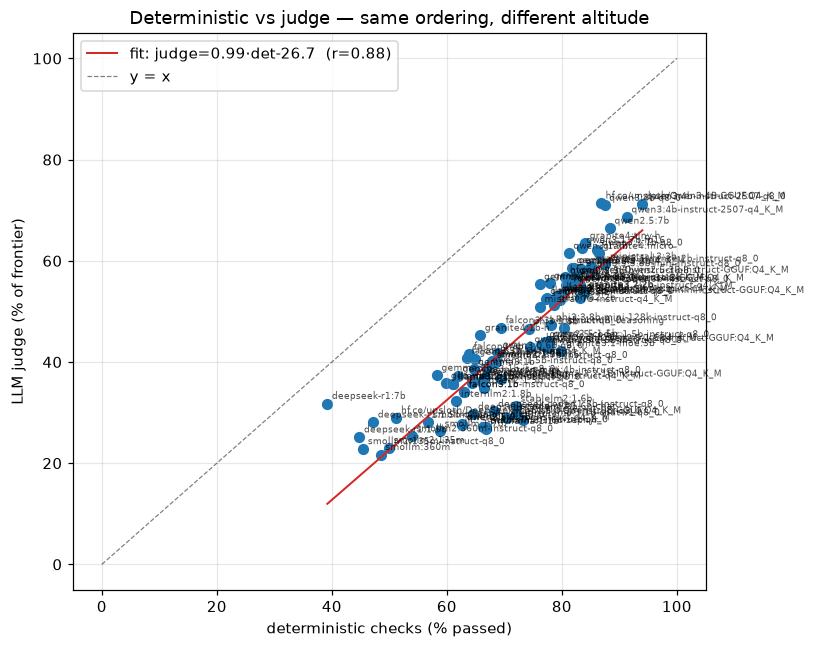

In [8]:
fig, ax = plt.subplots(figsize=(7.5, 6))
jm = (df.claude + df.gpt) / 2          # ensemble judge per answer
g = df.assign(judge=jm / 5 * 100, detp=df.det * 100).groupby("model")
xx, yy = g.detp.mean(), g.judge.mean()
ax.scatter(xx, yy, s=40)
for m in xx.index:
    ax.annotate(m, (xx[m], yy[m]), fontsize=6, alpha=0.7,
                xytext=(3, 3), textcoords="offset points")
sl, ic, r, *_ = stats.linregress(xx, yy)
xs = np.linspace(xx.min(), xx.max(), 50)
ax.plot(xs, sl * xs + ic, "C3-", lw=1.3, label=f"fit: judge={sl:.2f}·det{ic:+.1f}  (r={r:.2f})")
ax.plot([0, 100], [0, 100], "k--", lw=0.8, alpha=0.5, label="y = x")
ax.set(xlabel="deterministic checks (% passed)", ylabel="LLM judge (% of frontier)",
       title="Deterministic vs judge — same ordering, different altitude")
ax.legend(); plt.tight_layout(); plt.show()


## 7. Agreement by task class

Does the judge–judge agreement hold across *every* kind of task, or only some?
Per-class QWK + how far apart the two judges' means are.

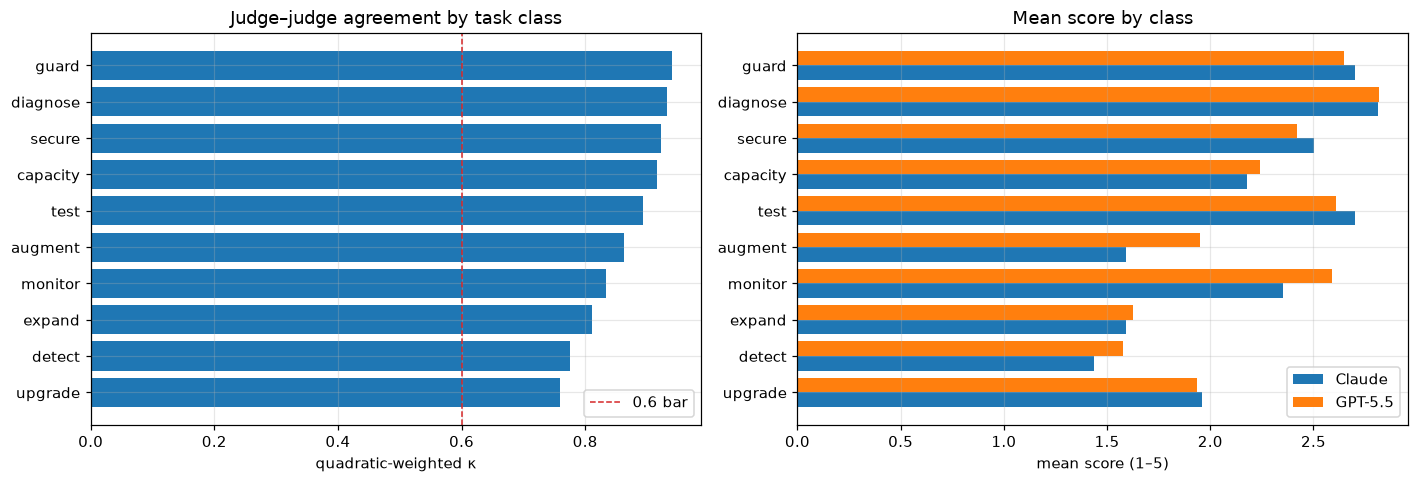

,cls,n,QWK,claude,gpt,det
9,upgrade,939,0.76,1.96,1.94,3.52
2,detect,469,0.78,1.43,1.58,4.14
4,expand,936,0.81,1.59,1.63,2.95
6,monitor,468,0.83,2.35,2.59,4.26
0,augment,469,0.86,1.59,1.95,2.51
8,test,470,0.89,2.70,2.61,4.34
1,capacity,1877,0.92,2.18,2.24,3.59
7,secure,2343,0.92,2.50,2.42,3.75
3,diagnose,470,0.93,2.81,2.82,4.78
5,guard,468,0.94,2.70,2.65,2.34


In [9]:
recs = []
for cls, gdf in df.groupby("class"):
    if len(gdf) < 5:
        continue
    aa, bb = gdf.claude.values, gdf.gpt.values
    recs.append(dict(cls=cls, n=len(gdf),
                     QWK=cohen_kappa(aa, bb, "quadratic"),
                     claude=aa.mean(), gpt=bb.mean(),
                     det=gdf.det.mean() * 5 if gdf.det.notna().any() else np.nan))
cl = pd.DataFrame(recs).sort_values("QWK")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
ax1.barh(cl.cls, cl.QWK, color="C0")
ax1.axvline(0.6, color="C3", ls="--", lw=1, label="0.6 bar")
ax1.set(xlabel="quadratic-weighted κ", title="Judge–judge agreement by task class")
ax1.legend()
w = 0.4
yy = np.arange(len(cl))
ax2.barh(yy - w/2, cl.claude, w, label="Claude", color="C0")
ax2.barh(yy + w/2, cl.gpt, w, label="GPT-5.5", color="C1")
ax2.set_yticks(yy, cl.cls); ax2.set(xlabel="mean score (1–5)", title="Mean score by class")
ax2.legend(); plt.tight_layout(); plt.show()
cl.round(2)


---
### Notes
- **VAR pass** (this view): R=5 — five samples/scenario, all 94 functional models = 8,909
  jointly-judged answers (consolidated, read from the committed `data/site/judge_pairs.csv`). Flip `PASS = "det"` for the temperature-0 single-sample
  view (475 answers). Fleiss' κ becomes available when a 3rd judge is added.
- **References:** Bland & Altman, *Lancet* 1986; Cohen, *Psych. Bull.* 1968
  (weighted κ); Landis & Koch, *Biometrics* 1977 (bands); Shrout & Fleiss,
  *Psych. Bull.* 1979 (ICC); see also `judge_agreement.py` (the CLI version).
